In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/ieee-fraud-detection/sample_submission.csv
/kaggle/input/ieee-fraud-detection/test_identity.csv
/kaggle/input/ieee-fraud-detection/train_identity.csv
/kaggle/input/ieee-fraud-detection/test_transaction.csv
/kaggle/input/ieee-fraud-detection/train_transaction.csv


In [3]:
!pip install mlflow dagshub --quiet

In [4]:
import mlflow
from dagshub import dagshub_logger
import os

# Set tracking URI manually
mlflow.set_tracking_uri("https://dagshub.com/ekvirika/FraudDerection.mlflow")

# Use your DagsHub credentials
os.environ["MLFLOW_TRACKING_USERNAME"] = "ekvirika"
os.environ["MLFLOW_TRACKING_PASSWORD"] = "3f601f2c2c7a6bca448ebc69f4f5d4b49daffd8f"

# Optional: set registry if you're using model registry
mlflow.set_registry_uri("https://dagshub.com/ekvirika/FraudDerection.mlflow")

# Cleaning and Preprocessing

Train shape after merge: (590540, 434)


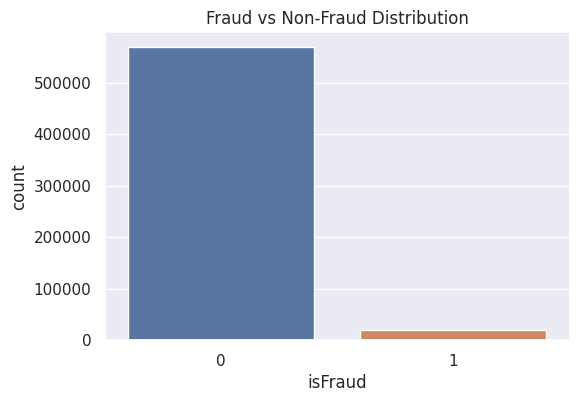

Fraud ratio: 3.50%


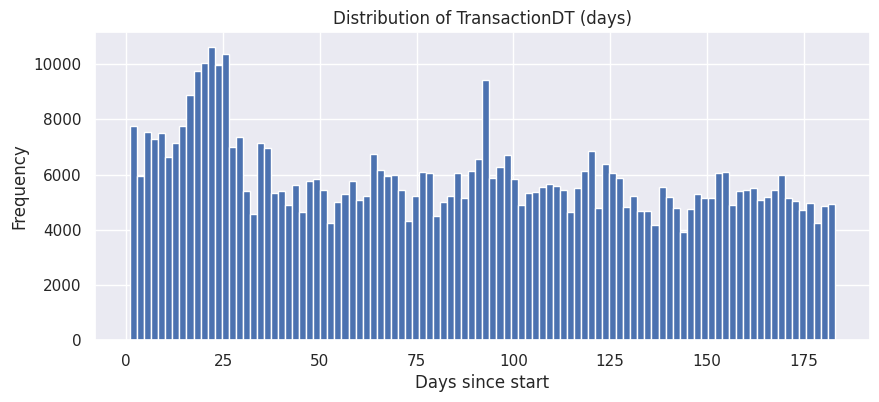

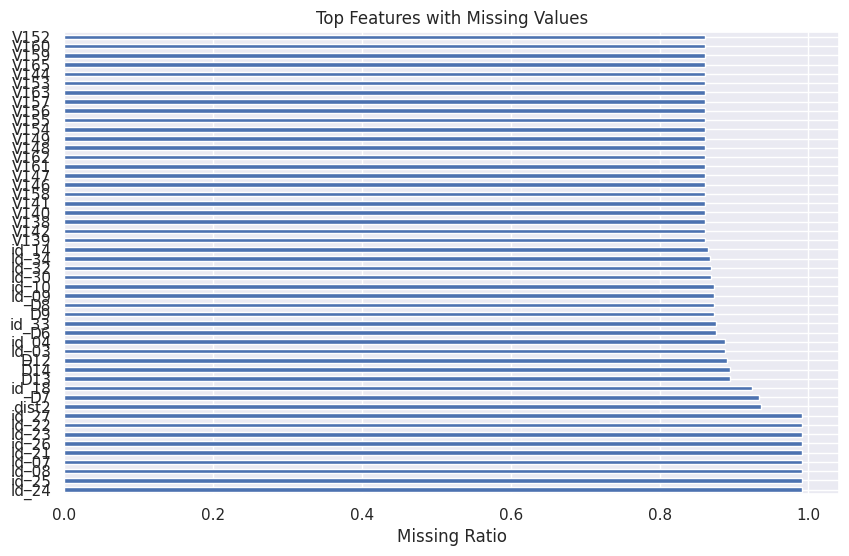

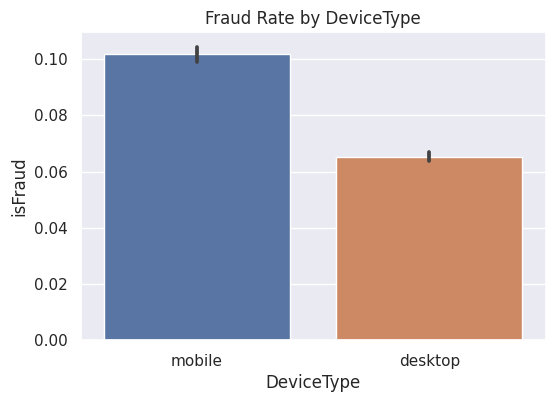

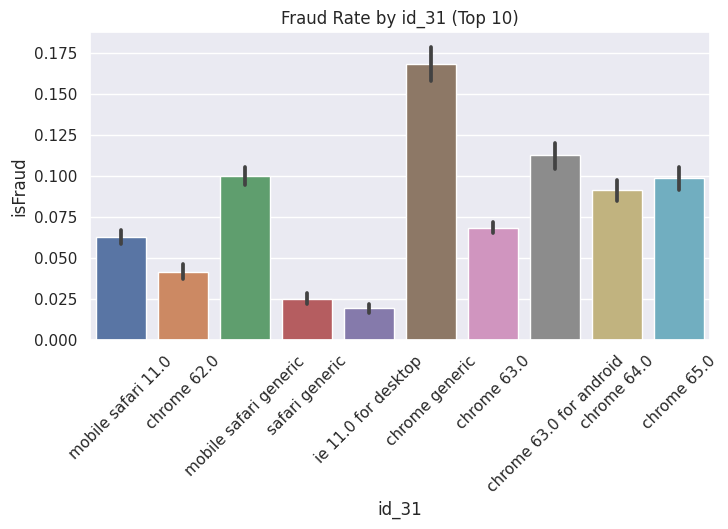

In [5]:
# 01_data_preprocessing_and_eda

# === Imports ===
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
sns.set(style='darkgrid')

# === Load Data ===
train_transaction = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_identity.csv')

# Merge on TransactionID
train = train_transaction.merge(train_identity, on='TransactionID', how='left')
print("Train shape after merge:", train.shape)

# === Target Distribution ===
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=train)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

print("Fraud ratio: {:.2f}%".format(train['isFraud'].mean() * 100))

# === TransactionDT Analysis ===
# Convert to timedelta days (roughly)
train['TransactionDT_days'] = train['TransactionDT'] / (3600 * 24)

plt.figure(figsize=(10, 4))
train['TransactionDT_days'].plot.hist(bins=100)
plt.title("Distribution of TransactionDT (days)")
plt.xlabel("Days since start")
plt.show()

# === Missing Values ===
missing = train.isnull().mean().sort_values(ascending=False)
missing = missing[missing > 0]

plt.figure(figsize=(10, 6))
missing.head(50).plot.barh()
plt.title("Top Features with Missing Values")
plt.xlabel("Missing Ratio")
plt.show()

# Save missing info
missing.to_csv('missing_value_ratios.csv')

# === DeviceType and id_31 effect ===
plt.figure(figsize=(6, 4))
sns.barplot(x='DeviceType', y='isFraud', data=train)
plt.title("Fraud Rate by DeviceType")
plt.show()

plt.figure(figsize=(8, 4))
top_id_31 = train['id_31'].value_counts().index[:10]
sns.barplot(x='id_31', y='isFraud', data=train[train['id_31'].isin(top_id_31)])
plt.xticks(rotation=45)
plt.title("Fraud Rate by id_31 (Top 10)")
plt.show()


# Feature Engineeering

In [6]:
import pandas as pd
import numpy as np
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.preprocessing import LabelEncoder
import logging
import hashlib

logging.basicConfig(level=logging.INFO, format='[%(levelname)s] %(message)s')

class FeatureEngineeringTransformer(BaseEstimator, TransformerMixin):
    def __init__(self):
        self.label_encoders = {}
        self.nan_fill_value = -999
        self.outlier_fill_value = -9999
        self.uid_cols = ['card1', 'card2', 'addr1']
        self.label_cols = []

    def fit(self, X, y=None):
        logging.info("Fitting FeatureEngineeringTransformer...")
        X = X.copy()

        # Label encode object (categorical) columns
        self.label_cols = X.select_dtypes(include='object').columns.tolist()
        for col in self.label_cols:
            X[col] = X[col].fillna('NA')
            le = LabelEncoder()
            try:
                le.fit(X[col])
                self.label_encoders[col] = le
            except Exception as e:
                logging.warning(f"LabelEncoder failed for {col}: {e}")

        logging.info(f"Fitted {len(self.label_cols)} categorical columns.")
        return self

    def transform(self, X):
        logging.info("Transforming dataset...")
        X = X.copy()
        X.fillna(self.nan_fill_value, inplace=True)

        # Label encode
        for col in self.label_cols:
            le = self.label_encoders.get(col)
            if le:
                try:
                    X[col] = le.transform(X[col].fillna('NA'))
                except Exception:
                    logging.warning(f"New unseen label in {col}, setting as 0")
                    X[col] = 0

        # Hash-based UID encoding
        uid_series = X[self.uid_cols[0]].astype(str)
        for col in self.uid_cols[1:]:
            uid_series += '_' + X[col].astype(str)

        def hash_uid(uid_str):
            return int(hashlib.md5(uid_str.encode()).hexdigest()[:8], 16)

        X['uid'] = uid_series.apply(hash_uid)

        # TransactionDT features
        X['TransactionDT_days'] = X['TransactionDT'] / (3600 * 24)
        X['Transaction_hour'] = (X['TransactionDT'] // 3600) % 24
        X['Transaction_day'] = (X['TransactionDT'] // (3600 * 24)) % 7

        # Cents from TransactionAmt
        X['TransactionAmt_cents'] = ((X['TransactionAmt'] - X['TransactionAmt'].astype(int)) * 100).astype(int)

        # Replace rare values
        for col in ['ProductCD', 'card4', 'card6']:
            if col in X.columns:
                freq = X[col].value_counts()
                rare_values = freq[freq < 100].index
                X[col] = X[col].replace(rare_values, self.outlier_fill_value)

        logging.info(f"Transformed shape: {X.shape}")
        return X


# Training

In [ ]:
# 03_model_training_with_mlflow.ipynb

# === Imports ===
import pandas as pd
import numpy as np
import mlflow
import mlflow.sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score
import lightgbm as lgb
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import f1_score
from sklearn.model_selection import GridSearchCV



# === Load Data ===
X = train.drop(columns=['isFraud'])
y = train['isFraud']

# === Train/Validation Split ===
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# === MLflow Setup ===
mlflow.set_experiment("LightGBM_Training")

with mlflow.start_run(run_name="lightgbm-baseline"):
    # === Define Model ===
    lgb_model = lgb.LGBMClassifier(
        n_estimators=1000,
        learning_rate=0.01,
        num_leaves=64,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        class_weight='balanced',
        objective='binary',
        metric='auc'
    )

    param_grid = {
        'model__n_estimators': [100],
        'model__learning_rate': [0.05],
        'model__num_leaves': [25],
        'model__max_depth': [10],
        'model__scale_pos_weight': [25]  # Try pos_weight = (neg / pos)
    }


    # === Pipeline ===
    pipeline = Pipeline([
        ('features', FeatureEngineeringTransformer()),
        ('model', lgb_model)
    ])



    grid_search = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        scoring='f1',
        cv=StratifiedKFold(n_splits=3, shuffle=True, random_state=42),
        verbose=2,
        n_jobs=1
    )

    grid_search.fit(X_train, y_train)

    print("Best F1 Score: ", grid_search.best_score_)
    print("Best Params: ", grid_search.best_params_)
    
    # Predict with best estimator
    from sklearn.metrics import f1_score

    

    best_model = grid_search.best_estimator_
    y_pred_proba = best_model.predict_proba(X_val)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)
    roc_auc = roc_auc_score(y_val, y_pred_proba)
    f1 = f1_score(y_val, y_pred)
    print("Validation F1: ", f1_score(y_val, y_pred))

    thresholds = np.arange(0.1, 0.9, 0.05)
    scores = [f1_score(y_val, y_pred_proba > t) for t in thresholds]
    best_thresh = thresholds[np.argmax(scores)]
    print(f"Best threshold for F1: {best_thresh}")

    # === Fit and Predict ===
    # logging.info("Training pipeline...")
    # pipeline.fit(X_train, y_train)
    # y_pred_proba = pipeline.predict_proba(X_val)[:, 1]
    # y_pred = (y_pred_proba >= 0.5).astype(int)
    # roc_auc = roc_auc_score(y_val, y_pred_proba)
    # f1 = f1_score(y_val, y_pred)


    # print(f"Validation AUC: {roc_auc:.5f}")

    import matplotlib.pyplot as plt

    # importances = best_model.named_steps['model'].feature_importances_
    # features = best_model.named_steps['features'].get_feature_names_out()
    
    # top_features = sorted(zip(features, importances), key=lambda x: x[1], reverse=True)[:30]
    # plt.barh([f[0] for f in top_features], [f[1] for f in top_features])
    # plt.gca().invert_yaxis()
    # plt.title("Top 30 Features")
    # plt.show()


    # === Log to MLflow ===
    mlflow.log_params(lgb_model.get_params())
    mlflow.log_metric("val_auc", roc_auc)
    mlflow.log_metric("f1_score", f1)
    mlflow.sklearn.log_model(pipeline, "model")
    logging.info(f"Validation ROC AUC: {roc_auc:.4f}")
    logging.info(f"Validation F1 Score: {f1:.4f}")
    print("Model logged to MLflow.")


In [11]:
# === Load Data ===
X = train.drop(columns=['isFraud'])
y = train['isFraud']

# === Train/Validation Split ===
X_train, X_val, y_train, y_val = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)


In [13]:
!pip install imbalanced-learn==0.11.0 --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.6/235.6 kB 6.2 MB/s eta 0:00:00:00:01


In [ ]:
import mlflow
import mlflow.sklearn
import logging
from sklearn.metrics import f1_score, roc_auc_score
from sklearn.model_selection import train_test_split
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import RandomOverSampler, SMOTE
from imblearn.under_sampling import RandomUnderSampler
from lightgbm import LGBMClassifier

# --- Define balancing strategies ---
resampling_methods = {
    "no_resampling": None,
    "scale_pos_weight": "scale_pos_weight",
    "class_weight_balanced": "class_weight",
    "random_oversampler": RandomOverSampler(random_state=42),
    "smote": SMOTE(random_state=42),
    "random_undersampler": RandomUnderSampler(random_state=42)
}

from sklearn.feature_selection import SelectKBest, mutual_info_classif

def run_experiment(X_train, X_val, y_train, y_val):
    for name, method in resampling_methods.items():
        with mlflow.start_run(run_name=f"lgbm_{name}"):
            logging.info(f"Running resampling strategy: {name}")
            
            # Feature selector
            feature_selector = SelectKBest(score_func=mutual_info_classif, k=50)

            if method is None:
                model = LGBMClassifier(random_state=42)
                steps = [
                    ("feature_engineering", FeatureEngineeringTransformer()),
                    ("feature_selection", feature_selector),
                    ("model", model)
                ]
            elif method == "scale_pos_weight":
                model = LGBMClassifier(scale_pos_weight=27.6, random_state=42)
                steps = [
                    ("feature_engineering", FeatureEngineeringTransformer()),
                    ("feature_selection", feature_selector),
                    ("model", model)
                ]
            elif method == "class_weight":
                model = LGBMClassifier(class_weight="balanced", random_state=42)
                steps = [
                    ("feature_engineering", FeatureEngineeringTransformer()),
                    ("feature_selection", feature_selector),
                    ("model", model)
                ]
            else:
                model = LGBMClassifier(random_state=42)
                steps = [
                    ("feature_engineering", FeatureEngineeringTransformer()),
                    ("resample", method),
                    ("feature_selection", feature_selector),
                    ("model", model)
                ]

            pipeline = ImbPipeline(steps)
            pipeline.fit(X_train, y_train)
            y_pred = pipeline.predict(X_val)
            y_pred_proba = pipeline.predict_proba(X_val)[:, 1]

            f1 = f1_score(y_val, y_pred)
            auc = roc_auc_score(y_val, y_pred_proba)

            mlflow.log_param("resampling", name)
            mlflow.log_param("feature_selection", "SelectKBest(mutual_info)")
            mlflow.log_metric("f1_score", f1)
            mlflow.log_metric("roc_auc", auc)

            logging.info(f"{name} - F1: {f1:.4f}, ROC AUC: {auc:.4f}")

In [ ]:
run_experiment(X_train, X_val, y_train, y_val)


In [ ]:
train_transaction = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_transaction.csv')
train_identity = pd.read_csv('/kaggle/input/ieee-fraud-detection/train_identity.csv')